In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 


In [2]:
# Lets import some libraries
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf


%matplotlib inline

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
# Some basic parameters


RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well


EPOCHS = 30        # number of epochs
ALPHA = 0.001        # learning rate
BATCH_SIZE = 32      # other sizes leave last batch partial

TEST_SIZE=0.2
TIME_STEPS=24


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'medium',
          'figure.figsize'  : (15,6),
          'axes.labelsize'  : 'medium',
          'axes.titlesize'  :'medium',
          'xtick.labelsize' :'medium',
          'ytick.labelsize' :'medium',
         }

CMAP = plt.cm.brg

plt.rcParams.update(params) # update rcParams

In [4]:
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

## Load Data

In [5]:
data_df = pd.read_csv('./weatherHistory.csv')
data_df.shape

(96453, 12)

In [6]:
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [7]:
data_df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [8]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


In [9]:
num_cols=['Temperature (C)','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)','Visibility (km)','Pressure (millibars)']

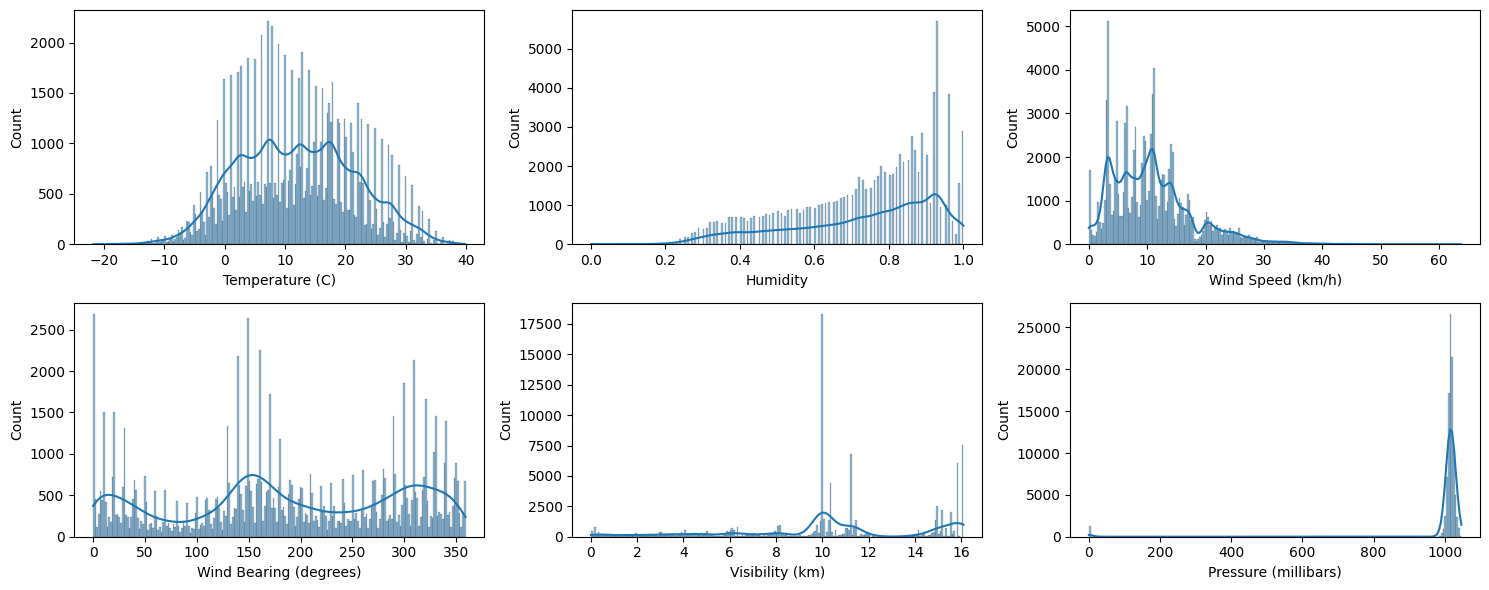

In [10]:
fig,axes=plt.subplots(2,3)

axes=axes.ravel()

for count, col in enumerate(num_cols):
    ax=axes[count]
    sns.histplot(data=data_df, x= col, ax=ax, bins=220,kde=True)

plt.tight_layout()
plt.show()


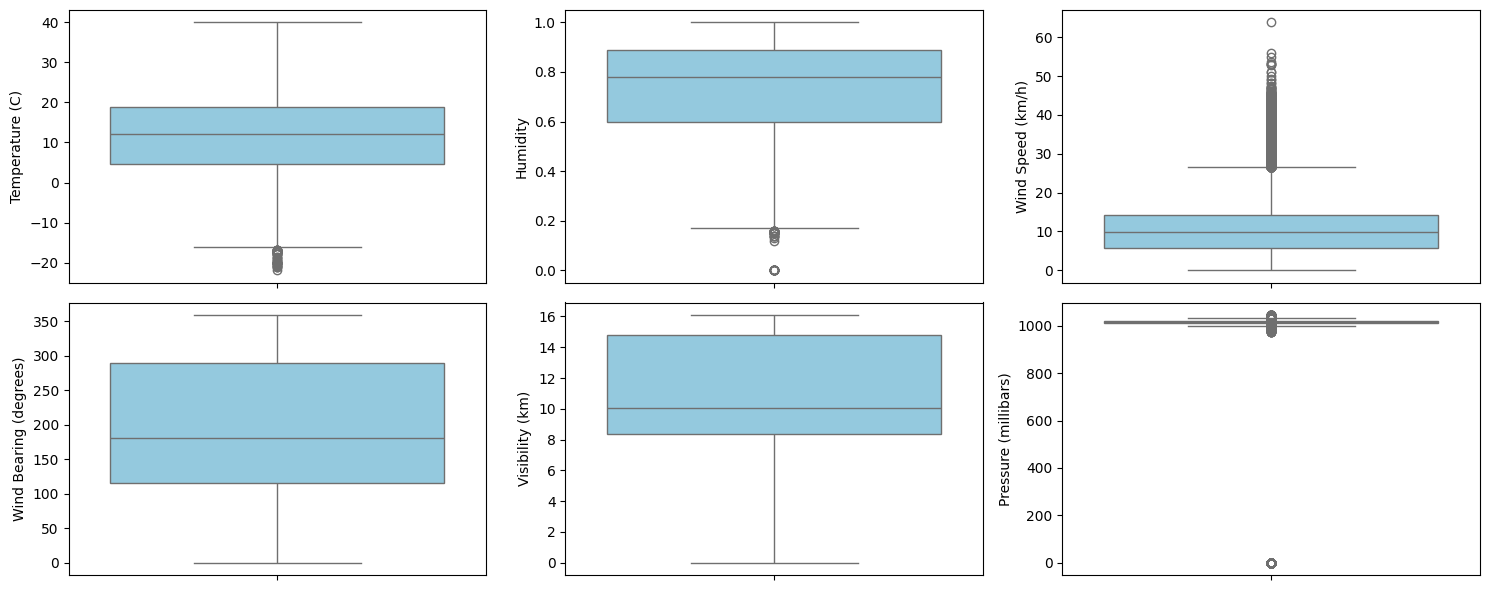

In [11]:
fig,axes=plt.subplots(2,3)

axes=axes.ravel()

for count, col in enumerate(num_cols):
    ax=axes[count]
    sns.boxplot(data=data_df, y= col, ax=ax,color='skyblue')

plt.tight_layout()
plt.show()


<Axes: >

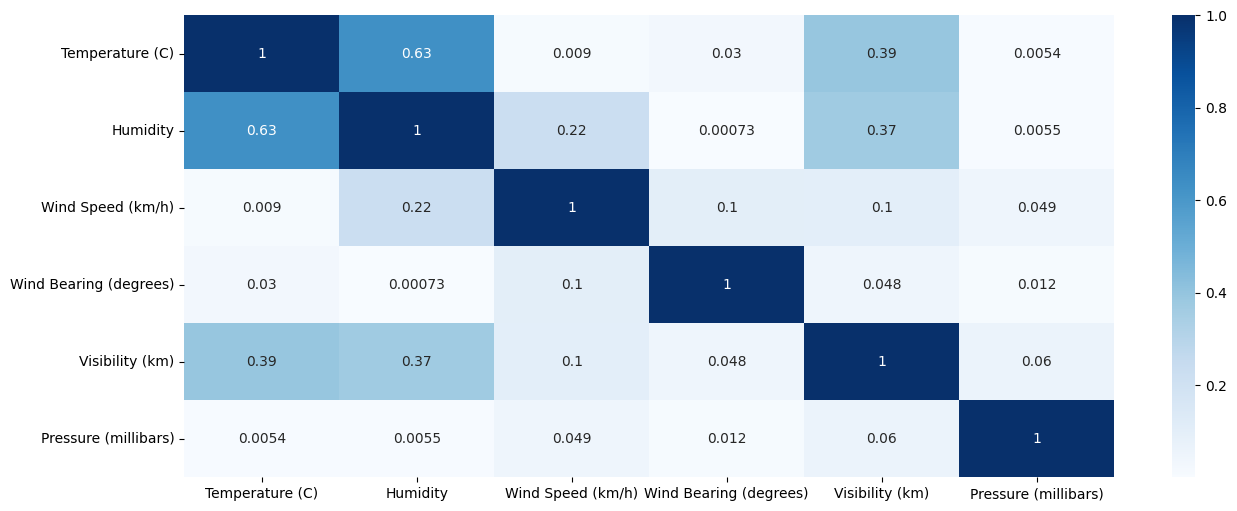

In [12]:
sns.heatmap(data_df[num_cols].corr().abs(), annot=True,cmap='Blues')

In [13]:
data_df['datetime']=pd.to_datetime(data_df['Formatted Date'],utc=True)
data_df=data_df.sort_values('datetime').reset_index(drop=True)
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-01-01 00:00:00.000 +0100,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.,2005-12-31 23:00:00+00:00
1,2006-01-01 01:00:00.000 +0100,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.,2006-01-01 00:00:00+00:00
2,2006-01-01 02:00:00.000 +0100,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.,2006-01-01 01:00:00+00:00
3,2006-01-01 03:00:00.000 +0100,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.,2006-01-01 02:00:00+00:00
4,2006-01-01 04:00:00.000 +0100,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.,2006-01-01 03:00:00+00:00


In [14]:
temp_df=data_df[['Temperature (C)','Humidity','datetime']].copy()
temp_df=temp_df.rename({'Temperature (C)':'temp', 'Humidity': 'hum'},axis=1)
temp_df=temp_df.reset_index(drop=True)
temp_df.head()

,temp,hum,datetime
0,0.577778,0.89,2005-12-31 23:00:00+00:00
1,1.161111,0.85,2006-01-01 00:00:00+00:00
2,1.666667,0.82,2006-01-01 01:00:00+00:00
3,1.711111,0.82,2006-01-01 02:00:00+00:00
4,1.183333,0.86,2006-01-01 03:00:00+00:00


In [15]:
X,y=[],[]
feature_cols=['temp','hum']

for i in range(0,len(temp_df)- TIME_STEPS, TIME_STEPS):
    X.append(temp_df.iloc[i:i+TIME_STEPS][feature_cols].to_numpy())
    y.append(temp_df.iloc[i:i+TIME_STEPS]['temp'])
X_data=np.array(X)
X_data=X_data[:,:-1,:]
y_data=np.array(y)
X_data.shape,y_data.shape

((4018, 23, 2), (4018, 24))

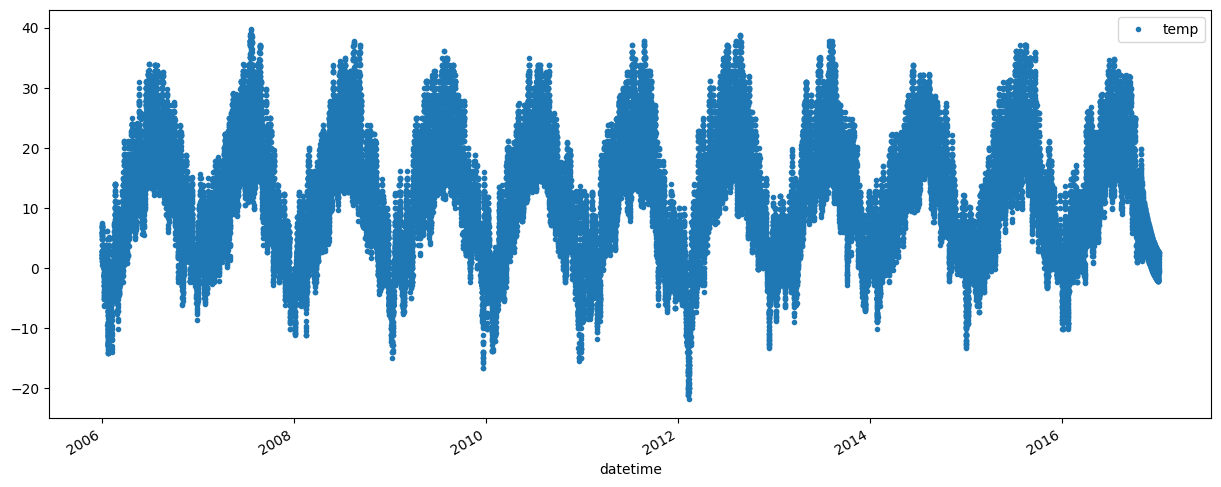

In [16]:
temp_df.plot(x='datetime',y='temp',style='.');

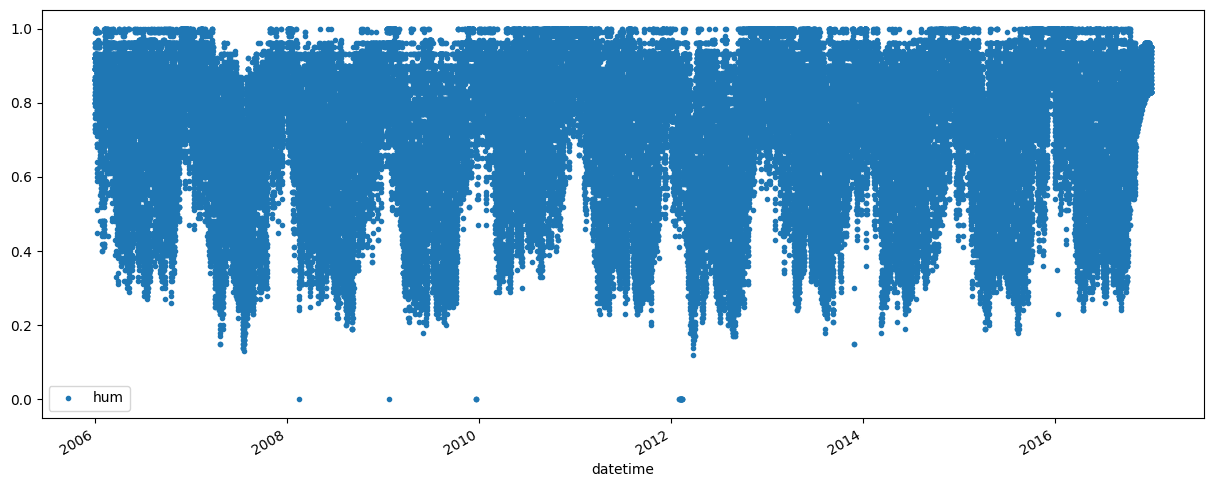

In [17]:
temp_df.plot(x='datetime',y='hum',style='.');

In [18]:
h_units=100    #hidden units
input_shape=(1,10000)

model=tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units, activation='tanh'))
model.add(tf.keras.layers.Dense(1,activation='linear'))

In [19]:
wax=model.get_weights()[0].shape
waa=model.get_weights()[1].shape

ba=model.get_weights()[2].shape
way=model.get_weights()[3].shape
by=model.get_weights()[4].shape

print(wax, waa,ba, way,by)

(10000, 100) (100, 100) (100,) (100, 1) (1,)


In [20]:
target_indices=np.arange(TIME_STEPS, len(temp_df),TIME_STEPS)

In [21]:
y_df=temp_df.iloc[target_indices].copy()
y_df.head()

,temp,hum,datetime
24,5.422222,0.86,2006-01-01 23:00:00+00:00
48,1.694444,0.92,2006-01-02 23:00:00+00:00
72,2.200000,0.89,2006-01-03 23:00:00+00:00
96,1.666667,0.92,2006-01-04 23:00:00+00:00
120,1.805556,0.99,2006-01-05 23:00:00+00:00


In [22]:
#getting feature dataset
X_df=temp_df.iloc[:len(y_df) * TIME_STEPS].copy()
X_df.shape,y_df.shape

((96432, 3), (4018, 3))

In [23]:
X=X_df['temp'].to_numpy().reshape(len(y_df),TIME_STEPS)
X.shape

(4018, 24)

In [24]:
#change X to first 23 columns
X=X[:,:TIME_STEPS-1]        #shape (n_sample, time_steps -1)
X.shape

(4018, 23)

In [25]:
y=y_df['temp'].to_numpy()
y.shape

(4018,)

In [26]:
split_ix=int(len(X) * (1-TEST_SIZE))
split_ix = split_ix // BATCH_SIZE * BATCH_SIZE
split_ix

3200

In [27]:
X_train, X_test= X[: split_ix], X[split_ix:]
y_train,y_test= y[:split_ix], y[split_ix:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 23), (818, 23), (3200,), (818,))

In [28]:
n_features=X_train.shape[2]
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d=X_train.reshape(-1,n_features)
X_test_2d=X_test.reshape(-1,n_features)

X_train_scaled = X_scaler.fit_transform(X_train_2d)
X_test_scaled = X_scaler.transform(X_test_2d)

X_train=X_train_scaled.reshape(X_train.shape)
X_test=X_test_scaled.reshape(X_test.shape)

y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

IndexError: tuple index out of range

## Converting to Datasets

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train,y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [ ]:
## Optimize for performance

train_ds = train_ds.cache()  # Cache first
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)


In [ ]:
for features, labels in train_ds.take(1):
    print (features.shape, labels.shape)

In [ ]:
## Some model functions
h_units=64

kernel_initializer= tf.keras.initializers.GlorotUniform(seed= RANDOM_STATE)

optimizer = 'adam' # using Adam optimizer

loss_fn ='mean_squared_error'
input_shape=(TIME_STEPS -1,1)
model=tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units,
                                    kernel_initializer=kernel_initializer,
                                    activation='tanh'))
model.add(tf.keras.layers.Dense(1,
                                kernel_initializer=kernel_initializer,
                                activation='linear'))

model.summary()

In [ ]:
model.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= [tf.keras.metrics.RootMeanSquaredError()])



In [ ]:
history = model.fit( train_ds,
                    epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2)

In [ ]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

In [ ]:


###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    

    

In [ ]:
fn_plot_tf_hist(hist_df)

In [ ]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

In [ ]:
proba_model1 = tf.keras.Sequential([model1,
                                   tf.keras.layers.Softmax()])

y_pred = proba_model1(X_test)

In [ ]:
class_name

In [ ]:
fn_plot_confusion_matrix(y_test, y_pred.numpy().argmax(axis = 1), labels=class_name)

## L2 Regularizer

L2 regularization (also called weight decay) adds a penalty term to the loss function:

**Loss = original_loss + $\lambda \cdot \sum(w^2)$**

This encourages weights to be small, preventing any single feature from dominating and reducing overfitting.

In [ ]:
## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

regularizer = tf.keras.regularizers.L2(0.05)

model2 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =( 34, ) ),

    tf.keras.layers.Dense (26,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer
    
    tf.keras.layers.Dense (18,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer

   tf.keras.layers.Dense (10,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer
    
    tf.keras.layers.Dense (2),
    
])

model2.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model2.fit(train_ds,
                    epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2)

hist_df = pd.DataFrame(history.history)

In [ ]:
fn_plot_tf_hist(hist_df)

## Batch Normalization
- Normalizes layer outputs to have mean ~0, variance ~1
- Allows higher learning rates
- Reduces internal covariate shift
- Has a slight regularization effect

In [ ]:
## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

model3 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    
    tf.keras.layers.Dense (18,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dense (10,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dense (2),
    
])


model3.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model3.fit(train_ds, 
                     epochs=EPOCHS,
                     batch_size = BATCH_SIZE,
                     validation_data=test_ds,
                     verbose = 2)

hist_df = pd.DataFrame(history.history)

In [ ]:
fn_plot_tf_hist(hist_df)

In [ ]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

## DROP OUTS

In [ ]:
rate1 = 0.2
rate2 = 0.3
rate3 = 0.4

## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

model4 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate1 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (18,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate2 , seed = RANDOM_STATE),

    tf.keras.layers.Dense (10,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate3 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (2),
    
])


model4.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model4.fit(train_ds,
                     epochs=EPOCHS,
                     batch_size = BATCH_SIZE,
                     validation_data=test_ds,
                     verbose = 2)

hist_df = pd.DataFrame(history.history)

In [ ]:
fn_plot_tf_hist(hist_df)

In [ ]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

### All In

In [ ]:
rate1 = 0.05
rate2 = 0.15
rate3 = 0.25

## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.AdamW(learning_rate=ALPHA, weight_decay=WEIGHT_DECAY) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

# Suppressing regularization
#regularizer = tf.keras.regularizers.L2(0.05)
regularizer = None

model = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate1 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (18,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate2 , seed = RANDOM_STATE),

    tf.keras.layers.Dense (10,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate3 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (2),
    
])

model.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])

In [ ]:
checkpoint_filepath = modelDir / subDir / 'all_in.keras'

# Model is saved at the end of every epoch, if it's the best seen so far.
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    verbose = 2,
    save_best_only=True
)

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=PATIENCE,
    mode='auto',
    verbose = 2,
    baseline =None,
    restore_best_weights=True)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=2,
    mode='auto',
    min_lr=0.00001)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logDir)

In [ ]:
history = model.fit(train_ds, 
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2,
                    callbacks = [es_callback, 
                                 chkpt_callback, 
                                 lr_callback, 
                                 tensorboard_callback])

hist_df = pd.DataFrame(history.history)

In [ ]:
fn_plot_tf_hist(hist_df)

In [ ]:
loss_dict = model.evaluate(test_ds, verbose=1 , return_dict=True)
loss_dict

In [ ]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

In [ ]:
del model
del model1
del model2
del model3
del model4

## Save Complete Model

In [ ]:
# Load the best model
model = tf.keras.models.load_model(checkpoint_filepath)

In [ ]:
model.summary()

In [ ]:
res = model.evaluate(test_ds, verbose=2, return_dict=True)

res['accuracy']

## Summary: Regularization Techniques Comparison

| Technique | Purpose | Key Parameter | Effect |
|-----------|---------|---------------|--------|
| L2 Regularization | Penalize large weights | $\lambda$ (lambda) | Smooths decision boundary |
| Dropout | Randomly disable neurons | dropout rate | Forces redundant learning |
| Batch Normalization | Normalize layer inputs | momentum | Faster, stable training |
| Early Stopping | Stop when val loss stops improving | patience | Prevents overfitting |
| Learning Rate Decay| Reduce when loss stops reducing | patience, LR factor | finetunes LR|

**Best Practice:** Combine techniques thoughtfully. Too much regularization = underfitting.